# OTF Scan --- Spectra & Maps

Load OTF scan dumps from `data/lab04/streaming/DR*/`,
apply fftshift, mask DC, RFI flagging, frequency-switch, and build
gridded HI spectra and maps in galactic coordinates.

See `02a_scan_diagnostics.ipynb` for pointing traces, outlier
diagnostics, and manifest updates.

In [1]:
import sys; sys.path.insert(0, '..')

# Ensure local utils/ is found before labs/02/utils/
import importlib
if 'utils' in sys.modules:
    del sys.modules['utils']
sys.path.insert(0, '.')

import ugradiolab.plotting as plotting  # applies rcParams
from ugradiolab.plotting import SS_FINE
from plotters import plot_spectra_grid, plot_heatmap, plot_survey_mollweide
from utils import (flag_rfi_channels, flag_outlier_dumps, vlsr_correction,
                   compute_R_for_dumps, compute_cell_W, build_heatmap)

from pathlib import Path
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

SAMPLE_RATE_HZ = 2.56e6
NFFT = 1024
HI_REST_MHZ = 1420.405
C_KMS = 299792.458

%matplotlib inline

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load all scan dumps

In [2]:
STREAMING_DIR = Path('../../../data/lab04/streaming')
DATA_RELEASES = ['DR1', 'DR2a', 'DR2b', 'DR3a', 'DR3b', 'DR4', 'DR5a', 'DR5b', 'DR6a', 'DR6b', 'DR7a', 'DR7b', 'DR8a', 'DR8b']

scan_dirs = []
for dr in DATA_RELEASES:
    dr_dir = STREAMING_DIR / dr
    if not dr_dir.exists():
        continue
    found = sorted(dr_dir.glob('scan_r*_c*'))
    print(f'{dr}: {len(found)} cells')
    scan_dirs.extend(found)

print(f'Total: {len(scan_dirs)} cells')

# Collect all dumps
records = []
for d in scan_dirs:
    dr_label = d.parent.name
    for p in sorted(d.glob('*.npz')):
        with np.load(p, allow_pickle=True) as f:
            records.append({
                'path': p,
                'dr': dr_label,
                'target': str(f['target_name']),
                'corr00': f['corr00'].astype(float),
                'corr11': f['corr11'].astype(float),
                'lo_mhz': float(f['lo_freq_mhz']),
                'noise_on': bool(f['noise_on']),
                'time': float(f['time']),
                'alt': float(f['alt_deg']),
                'az': float(f['az_deg']),
                'ra': float(f['ra_deg']),
                'dec': float(f['dec_deg']),
            })

N = len(records)
print(f'{N} total dumps loaded')

# Parse row/col from target name
import re
for r in records:
    m = re.match(r'scan_r(\d+)_c(\d+)', r['target'])
    if m:
        r['row'] = int(m.group(1))
        r['col'] = int(m.group(2))
    else:
        r['row'] = -1
        r['col'] = -1

rows = sorted(set(r['row'] for r in records if r['row'] >= 0))
cols = sorted(set(r['col'] for r in records if r['col'] >= 0))
lo_unique = sorted(set(r['lo_mhz'] for r in records if not r['noise_on']))
n_cal = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'])

for dr in DATA_RELEASES:
    n_dr = sum(1 for r in records if r['dr'] == dr)
    if n_dr > 0:
        print(f'  {dr}: {n_dr} dumps')
print(f'Grid: {len(rows)} rows x {len(cols)} cols')
print(f'Cal: {n_cal}, Science: {n_sci}')
print(f'LO frequencies: {lo_unique} MHz')

DR1: 153 cells
DR2a: 14 cells
DR2b: 95 cells
DR3a: 179 cells
DR3b: 80 cells
DR4: 226 cells
DR5a: 49 cells
DR5b: 241 cells
DR6a: 77 cells
DR6b: 37 cells
DR7a: 82 cells
DR7b: 15 cells
DR8a: 0 cells
DR8b: 19 cells
Total: 1267 cells
10879 total dumps loaded
  DR1: 1225 dumps
  DR2a: 432 dumps
  DR2b: 758 dumps
  DR3a: 1461 dumps
  DR3b: 641 dumps
  DR4: 2147 dumps
  DR5a: 407 dumps
  DR5b: 1935 dumps
  DR6a: 608 dumps
  DR6b: 295 dumps
  DR7a: 691 dumps
  DR7b: 120 dumps
  DR8b: 159 dumps
Grid: 15 rows x 52 cols
Cal: 84, Science: 10795
LO frequencies: [1420.0, 1421.0] MHz


## 2. fftshift + mask DC + RFI flagging

In [3]:
DC_BIN = NFFT // 2
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0/SAMPLE_RATE_HZ)) / 1e6
df_khz = SAMPLE_RATE_HZ / NFFT / 1e3

for r in records:
    r['corr00'] = np.fft.fftshift(r['corr00'])
    r['corr11'] = np.fft.fftshift(r['corr11'])

    # Mask DC bin (LO spike at baseband 0 = channel 512 after fftshift)
    r['corr00'][DC_BIN] = np.nan
    r['corr11'][DC_BIN] = np.nan

    # For LO=1420: mask 2 bins below DC to suppress leakage near HI line.
    if r['lo_mhz'] == 1420.0:
        for ch in [DC_BIN - 2, DC_BIN - 1]:
            r['corr00'][ch] = np.nan
            r['corr11'][ch] = np.nan

    r['stokes_I'] = r['corr00'] + r['corr11']

# RFI flagging: rolling median + MAD, flags both positive and
# negative outliers (spikes and dropouts).
RFI_WINDOW = 15
RFI_SIGMA = 5.0
n_flagged = sum(flag_rfi_channels(r['stokes_I'], RFI_WINDOW, RFI_SIGMA)
                for r in records)

print(f'Baseband: [{f_bb_mhz[0]:.3f}, {f_bb_mhz[-1]:.3f}] MHz')
print(f'dnu = {df_khz:.2f} kHz')
print(f'Masked DC bin: channel {DC_BIN}')
print(f'Masked DC leakage: channels {DC_BIN-2}, {DC_BIN-1} (LO=1420 only)')
print(f'RFI flagged: {n_flagged} samples across {N} dumps')

Baseband: [-1.280, 1.278] MHz
dnu = 2.50 kHz
Masked DC bin: channel 512
Masked DC leakage: channels 510, 511 (LO=1420 only)
RFI flagged: 890742 samples across 10879 dumps


In [4]:
import warnings

SHAPE_DEV_THRESH = 0.10
SHAPE_FRAC_THRESH = 0.20

outlier_records = flag_outlier_dumps(records, SHAPE_DEV_THRESH, SHAPE_FRAC_THRESH)
n_outlier_removed = len(outlier_records)
N = len(records)

print(f'Outlier dump filter (spectral shape): removed {n_outlier_removed} dumps')
print(f'  (flag if >{SHAPE_FRAC_THRESH:.0%} of channels deviate '
      f'>{SHAPE_DEV_THRESH:.0%} from group median)')
print(f'Remaining: {N} dumps')

Outlier dump filter (spectral shape): removed 128 dumps
  (flag if >20% of channels deviate >10% from group median)
Remaining: 10751 dumps


## 3. Frequency-switched profiles per cell

For each cell, pair dumps at the two LO frequencies and compute
`R = (I1 - I2) / I2`.

**LSR correction**: Each dump's topocentric velocity is shifted to the
kinematic LSR frame (solar motion 20 km/s toward 18h +30deg B1900).
Per-DR results stay in the topocentric frame (intra-session shift < 0.01 km/s).
Combined results interpolate each DR onto a common LSR velocity grid before
averaging, correcting for Earth's orbital motion between sessions.

In [5]:
import astropy.coordinates as ac
import astropy.units as u_ast
from astropy.time import Time as AstroTime
from collections import defaultdict

EDGE_TRIM_MHZ = 0.256

lo1, lo2 = lo_unique[0], lo_unique[1]
f_sky = lo1 + f_bb_mhz
f_sky_2 = lo2 + f_bb_mhz
f_overlap_lo = max(f_sky[0], f_sky_2[0]) + EDGE_TRIM_MHZ
f_overlap_hi = min(f_sky[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
overlap_mask = (f_sky >= f_overlap_lo) & (f_sky <= f_overlap_hi)
f_overlap = f_sky[overlap_mask]
v_overlap = C_KMS * (1 - f_overlap / HI_REST_MHZ)  # topocentric

print(f'LO pair: ({lo1}, {lo2}) MHz')
print(f'Overlap: [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz')
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')

# --- Assign galactic coords ---
for r in records:
    if r['row'] < 0:
        r['gl'], r['gb'] = None, None
        continue
    c = ac.SkyCoord(ra=r['ra'] * u_ast.deg, dec=r['dec'] * u_ast.deg, frame='icrs')
    r['gl'] = round(c.galactic.l.deg)
    r['gb'] = round(c.galactic.b.deg)

# --- LSR velocity correction ---
# v_LSR = v_topo + v_corr, where v_corr = heliocentric + solar motion to LSRK.
# Compute one correction per (DR, cell) group -- all dumps in a group are
# taken within minutes, so share the same correction to < 0.01 km/s.
print('Computing LSR corrections...')
cell_dr_groups = defaultdict(list)
for r in records:
    if r.get('gl') is None or r['noise_on']:
        r['v_corr_lsr'] = 0.0
        continue
    cell_dr_groups[(r['dr'], r['gl'], r['gb'])].append(r)

for key, group in cell_dr_groups.items():
    r0 = group[0]
    mean_t = np.mean([r['time'] for r in group])
    v_corr = vlsr_correction(r0['ra'], r0['dec'], mean_t)
    for r in group:
        r['v_corr_lsr'] = v_corr

sci_vcorr = [r['v_corr_lsr'] for r in records
             if r.get('gl') is not None and not r['noise_on']]
mean_vcorr = np.mean(sci_vcorr)
print(f'  Range: {min(sci_vcorr):.2f} to {max(sci_vcorr):.2f} km/s '
      f'(mean {mean_vcorr:.2f})')

# Common LSR velocity grid for combined results
v_lsr_overlap = v_overlap + mean_vcorr
print(f'Velocity (LSR):  [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')

# Per-DR LSR corrections
for dr in DATA_RELEASES:
    dr_vc = [r['v_corr_lsr'] for r in records
             if r.get('dr') == dr and r.get('gl') is not None and not r['noise_on']]
    if dr_vc:
        print(f'  {dr}: v_corr = {np.mean(dr_vc):+.2f} km/s '
              f'(shift vs ref: {np.mean(dr_vc) - mean_vcorr:+.2f})')

# --- All unique (l, b) pointings ---
all_pointings = sorted(set((r['gl'], r['gb']) for r in records
                           if r['gl'] is not None))

# --- Build results ---
cell_results = {}           # per-DR, topocentric (for per-DR plots)
cell_results_combined = {}  # combined, LSR-corrected

for gl, gb in all_pointings:
    sci_dumps = [r for r in records
                 if r['gl'] == gl and r['gb'] == gb and not r['noise_on']]

    # Combined with LSR correction
    result = compute_R_for_dumps(sci_dumps, lo1, lo2, overlap_mask, v_overlap,
                                 lsr_correct=True, v_lsr_grid=v_lsr_overlap)
    if result is not None:
        cell_results_combined[(gl, gb)] = result

    # Per DR (topocentric -- intra-session shift is negligible)
    for dr in DATA_RELEASES:
        dr_dumps = [r for r in sci_dumps if r['dr'] == dr]
        result = compute_R_for_dumps(dr_dumps, lo1, lo2, overlap_mask, v_overlap)
        if result is not None:
            cell_results[(dr, gl, gb)] = result

for dr in DATA_RELEASES:
    n = sum(1 for k in cell_results if k[0] == dr)
    print(f'  {dr}: {n} cells')
print(f'  Combined (LSR): {len(cell_results_combined)} cells')

LO pair: (1420.0, 1421.0) MHz
Overlap: [1419.98, 1421.02] MHz
Velocity (topo): [-130, 90] km/s
Computing LSR corrections...
  Range: -43.79 to 43.33 km/s (mean -13.49)
Velocity (LSR):  [-143, 77] km/s
  DR1: v_corr = +24.45 km/s (shift vs ref: +37.94)
  DR2a: v_corr = -33.58 km/s (shift vs ref: -20.10)
  DR2b: v_corr = +11.25 km/s (shift vs ref: +24.74)
  DR3a: v_corr = -35.26 km/s (shift vs ref: -21.78)
  DR3b: v_corr = +28.55 km/s (shift vs ref: +42.04)
  DR4: v_corr = -32.61 km/s (shift vs ref: -19.12)
  DR5a: v_corr = +10.97 km/s (shift vs ref: +24.45)
  DR5b: v_corr = -37.16 km/s (shift vs ref: -23.67)
  DR6a: v_corr = -15.17 km/s (shift vs ref: -1.69)
  DR6b: v_corr = -30.40 km/s (shift vs ref: -16.91)
  DR7a: v_corr = +41.28 km/s (shift vs ref: +54.77)
  DR7b: v_corr = -11.01 km/s (shift vs ref: +2.48)
  DR8b: v_corr = -33.90 km/s (shift vs ref: -20.42)


/home/ikaros/projects/ay-121/labs/04/notebooks/utils/freqswitch.py:68: RuntimeWarning: Mean of empty slice
  R_dr = np.nanmean(R_pairs, axis=0)
/home/ikaros/projects/ay-121/labs/04/notebooks/utils/freqswitch.py:91: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R_all, axis=0)
/home/ikaros/projects/ay-121/labs/04/notebooks/utils/freqswitch.py:98: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R_cat, axis=0)


  DR1: 153 cells
  DR2a: 14 cells
  DR2b: 95 cells
  DR3a: 179 cells
  DR3b: 80 cells
  DR4: 248 cells
  DR5a: 49 cells
  DR5b: 241 cells
  DR6a: 76 cells
  DR6b: 37 cells
  DR7a: 76 cells
  DR7b: 15 cells
  DR8a: 0 cells
  DR8b: 18 cells
  Combined (LSR): 1272 cells


## 4. HI map

Velocity-integrated R over the full overlap bandwidth (256 kHz trimmed edges).

W = Sigma R(v) x Deltav [km/s]

dv = 0.528 km/s per channel
Overlap channels: 418
Total velocity range: 220.6 km/s


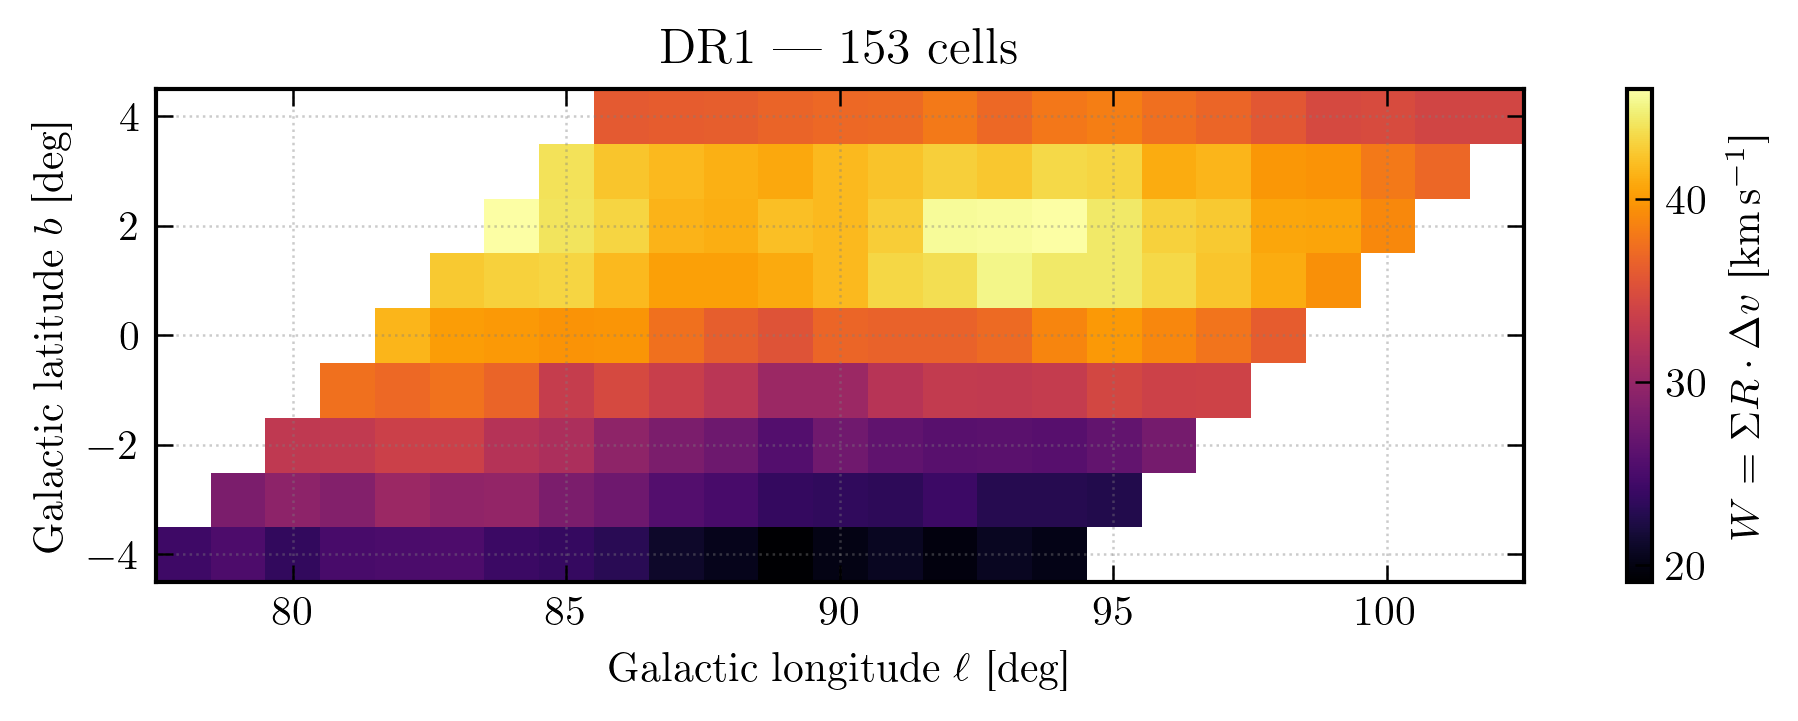

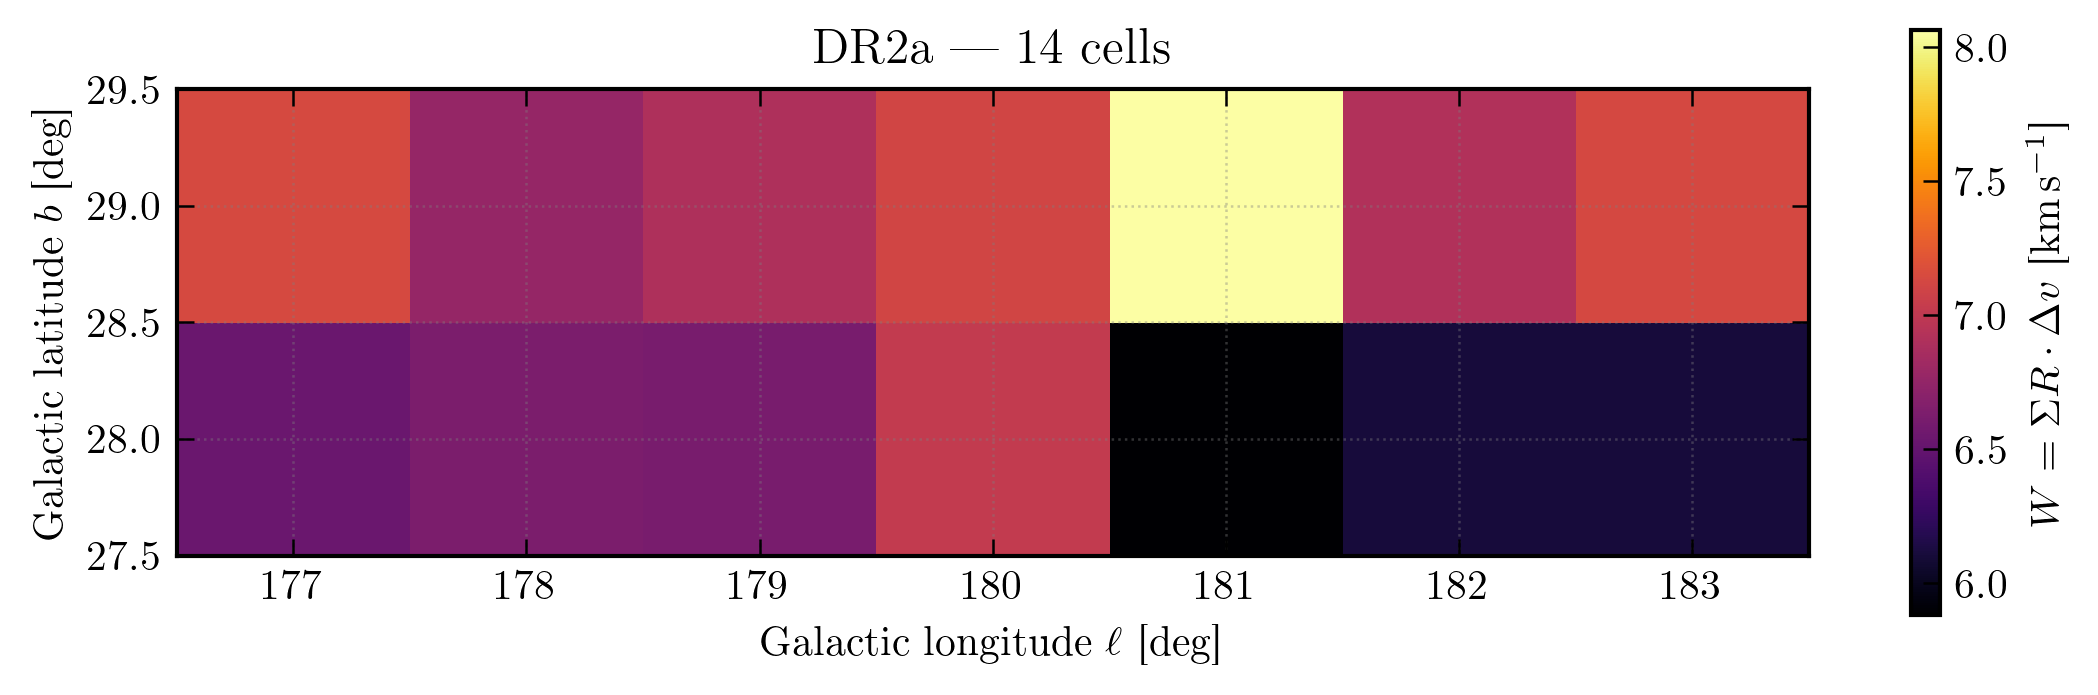

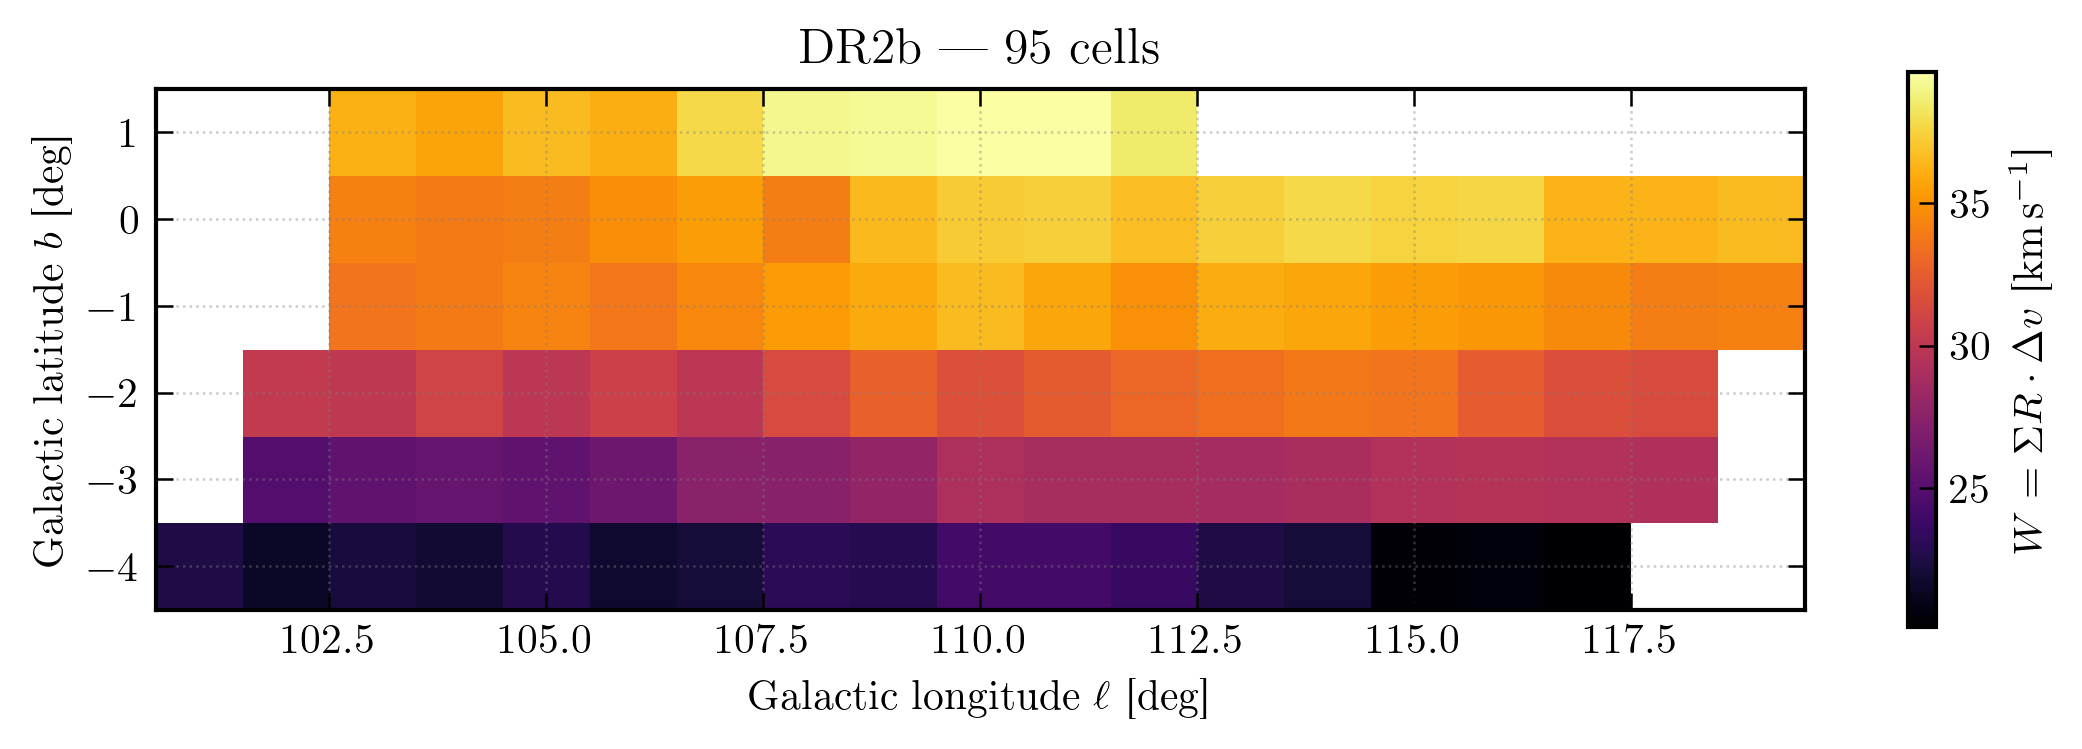

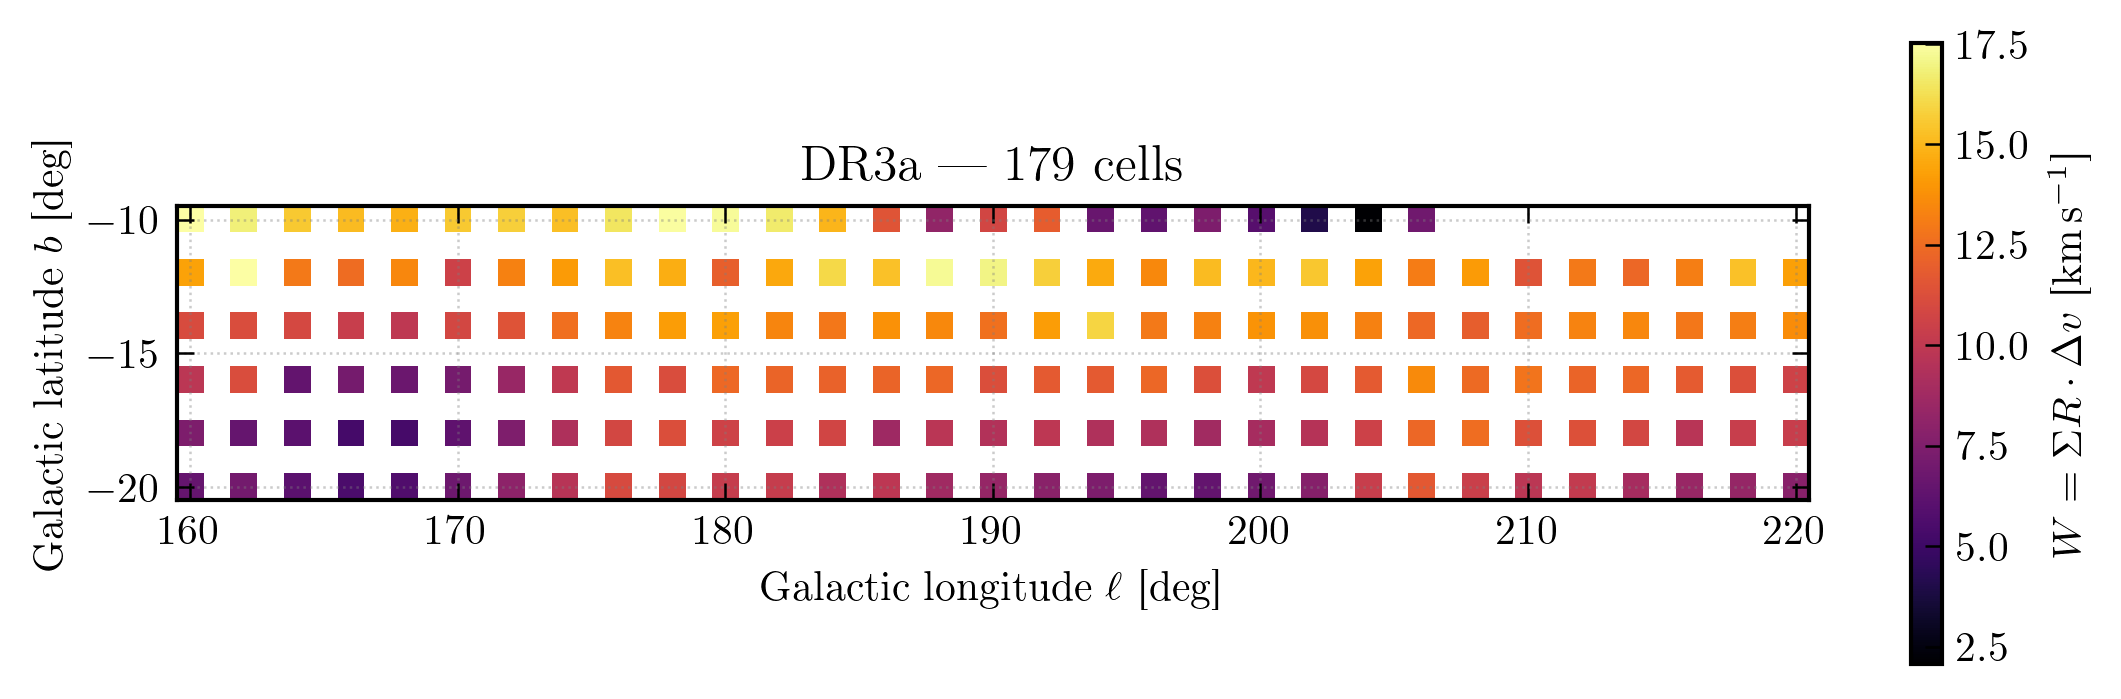

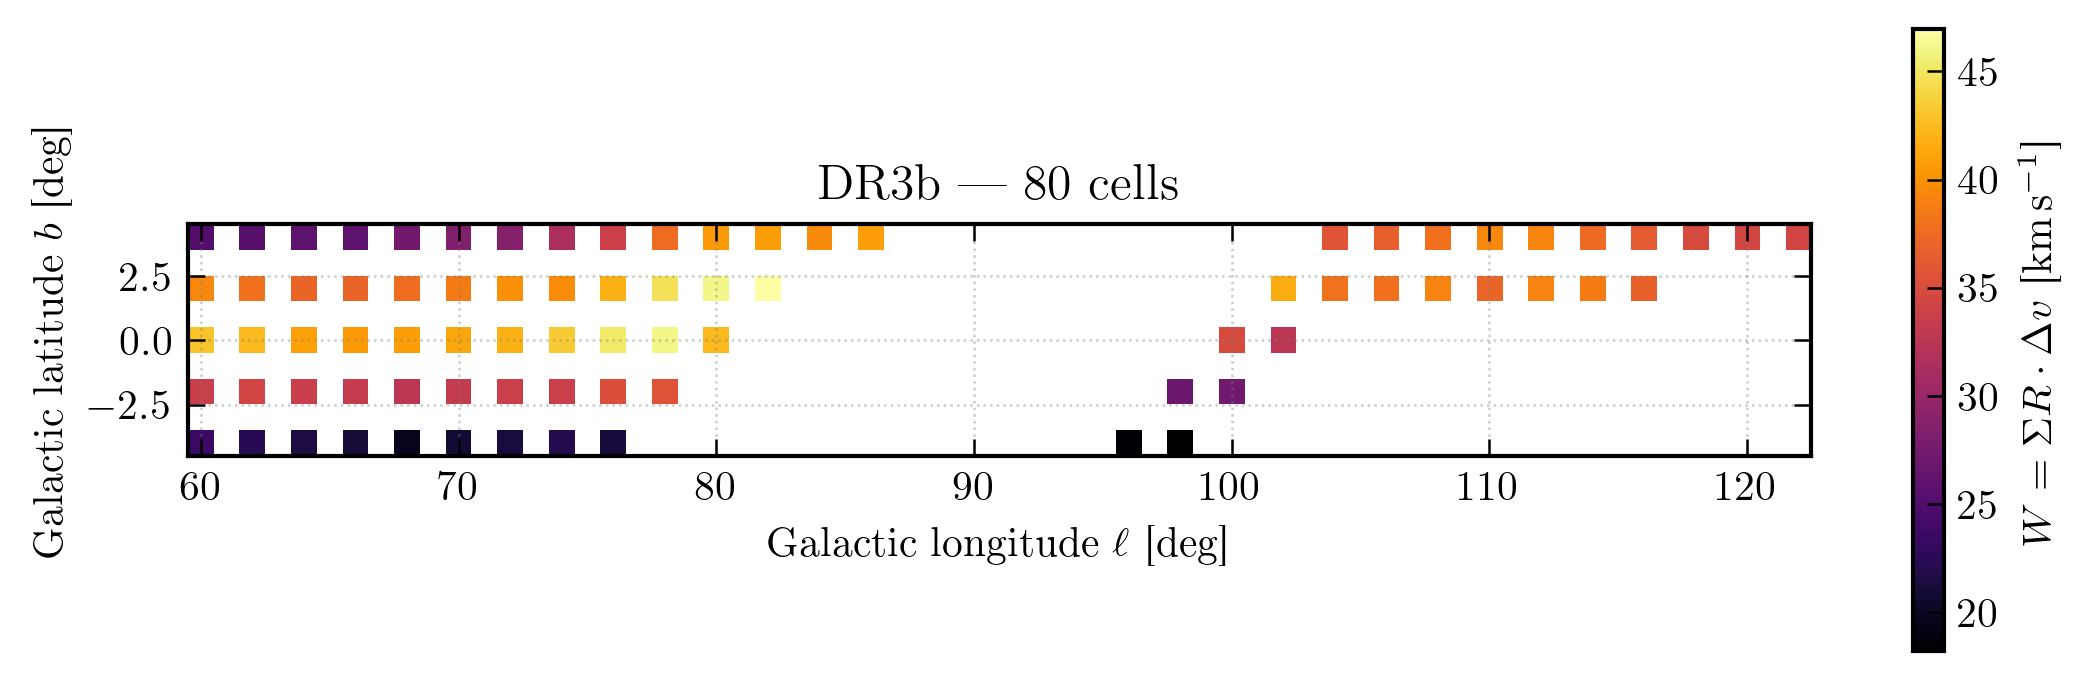

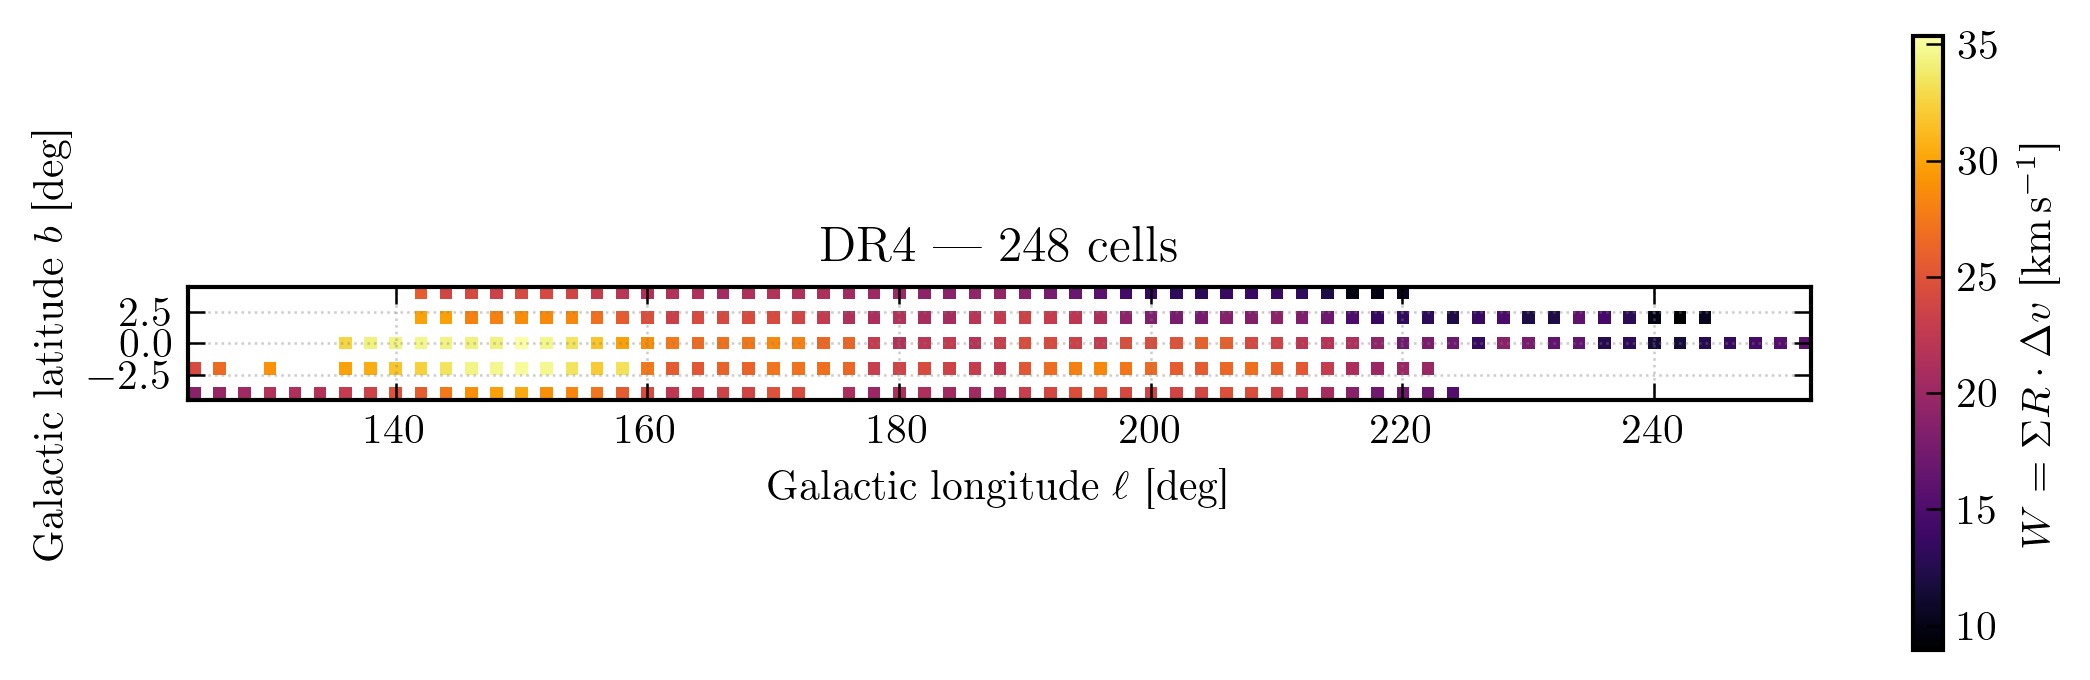

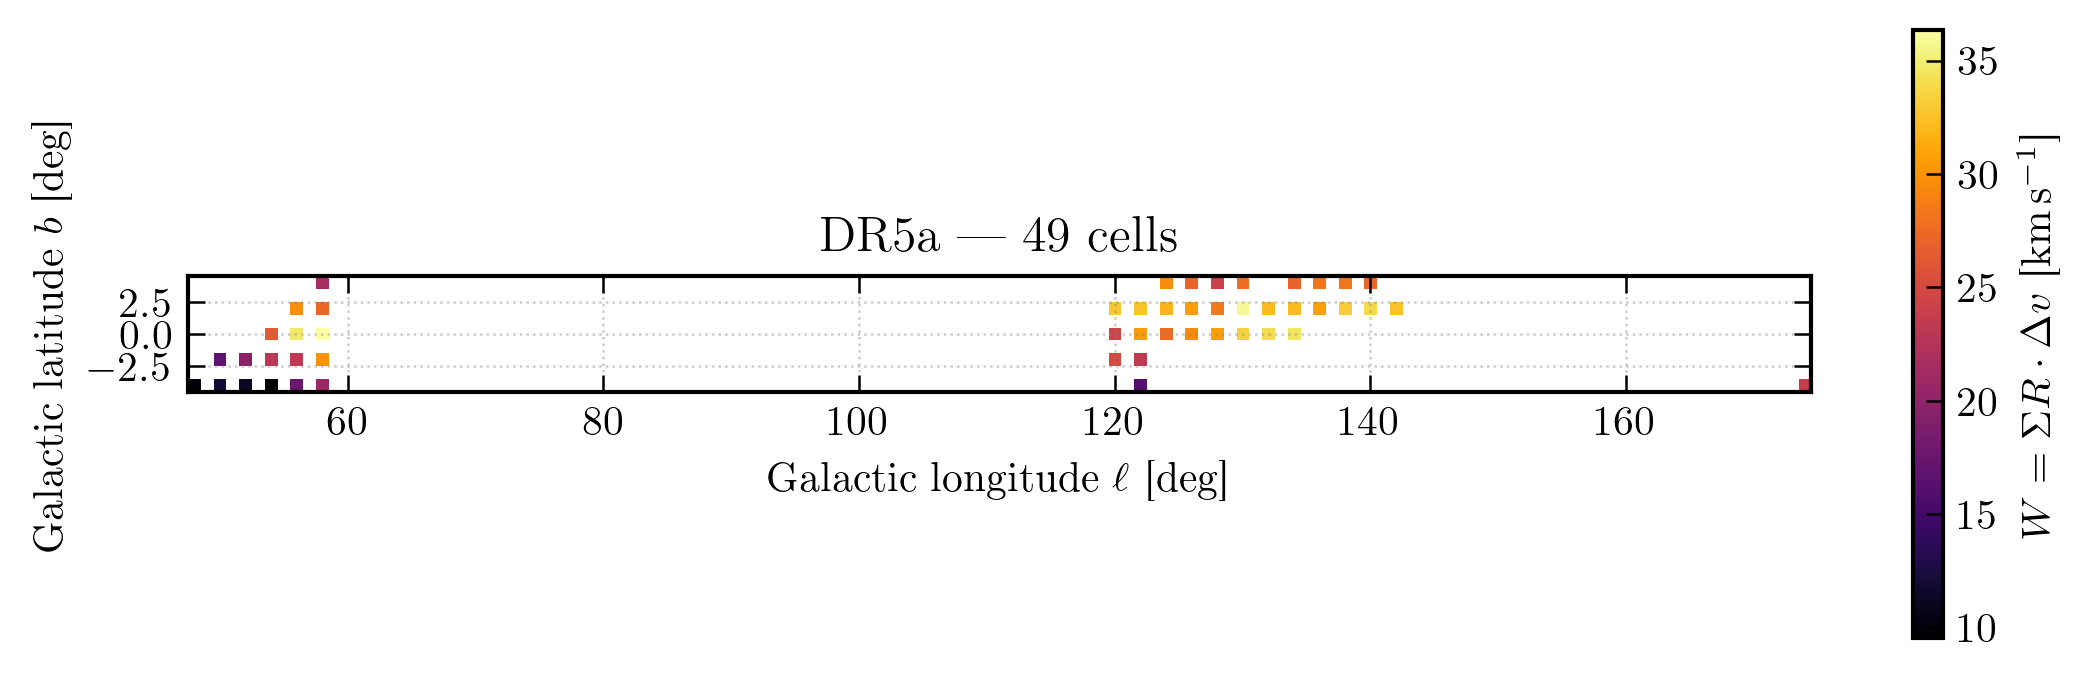

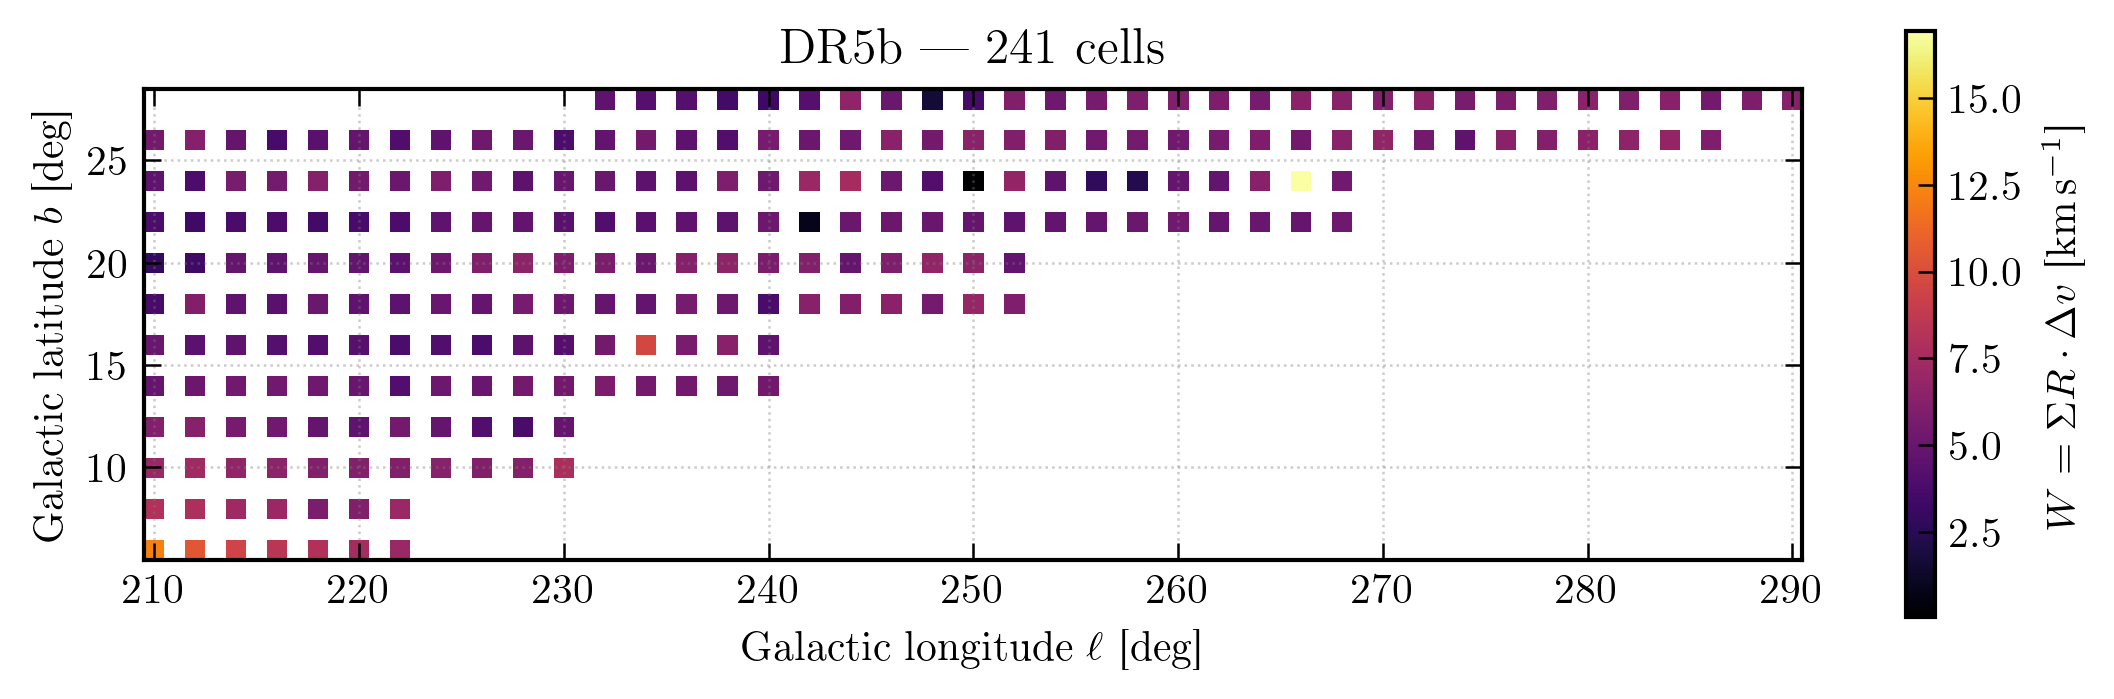

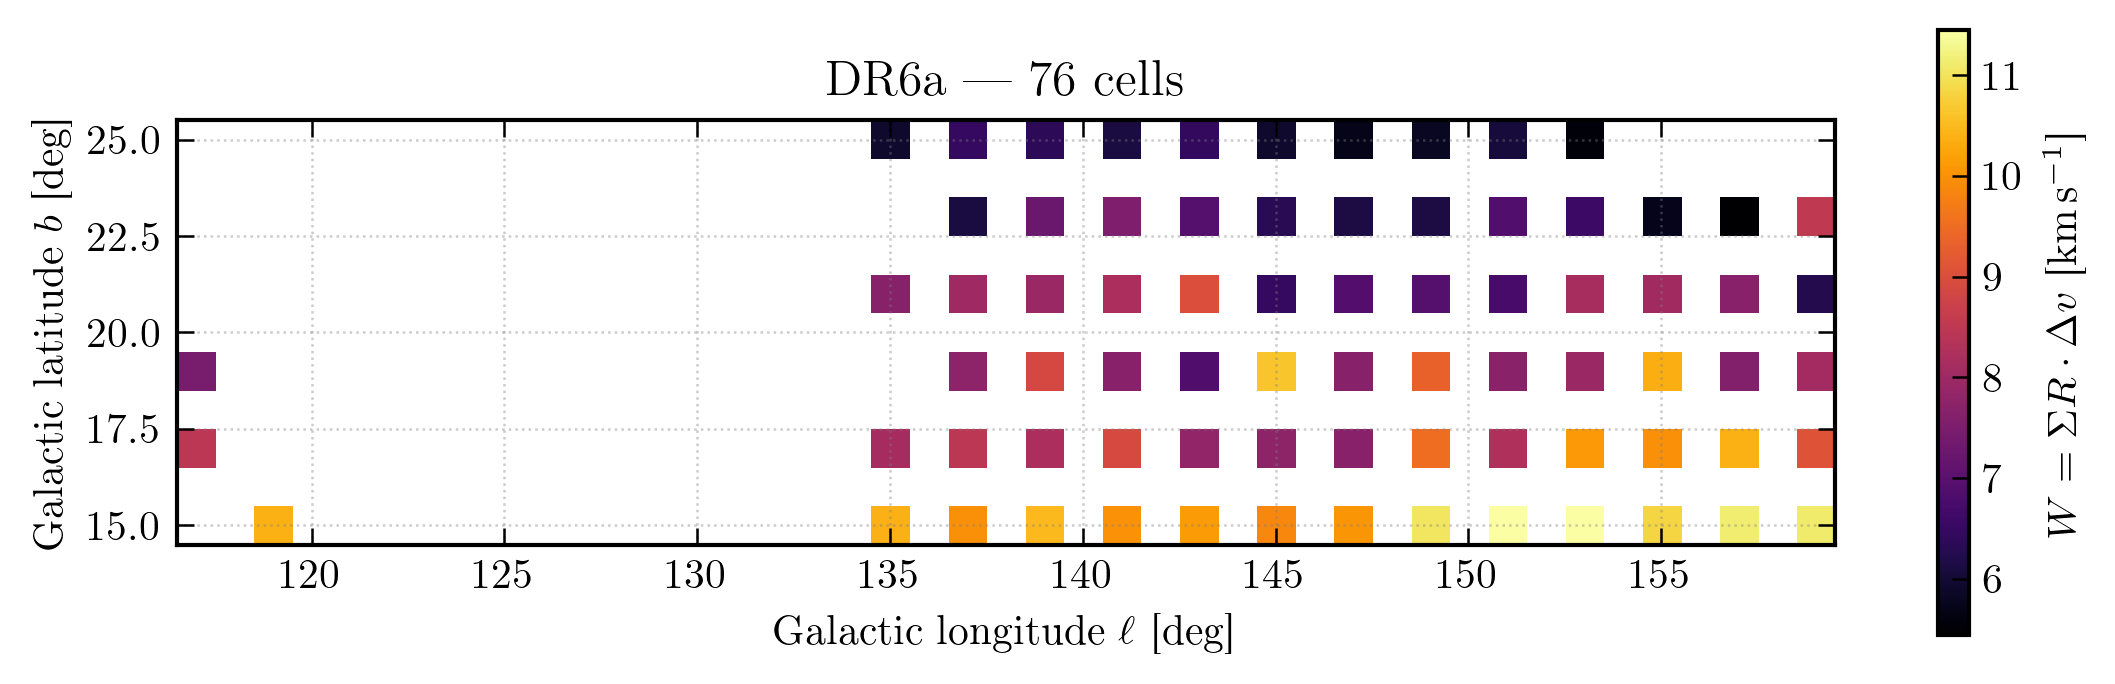

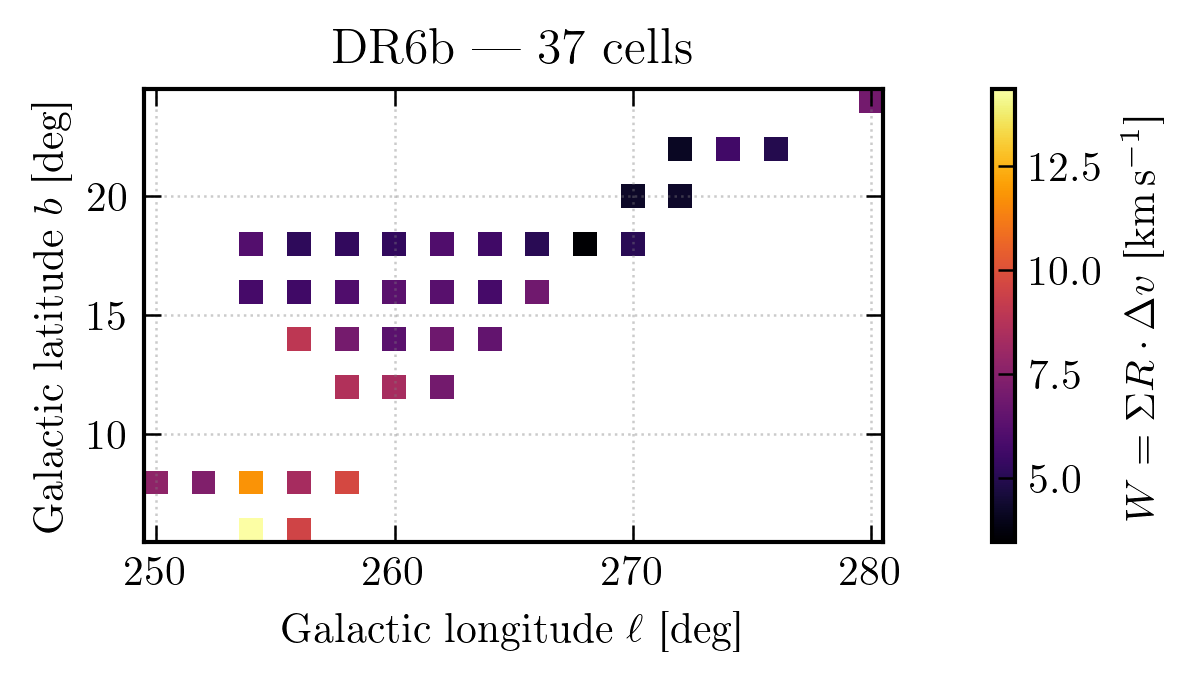

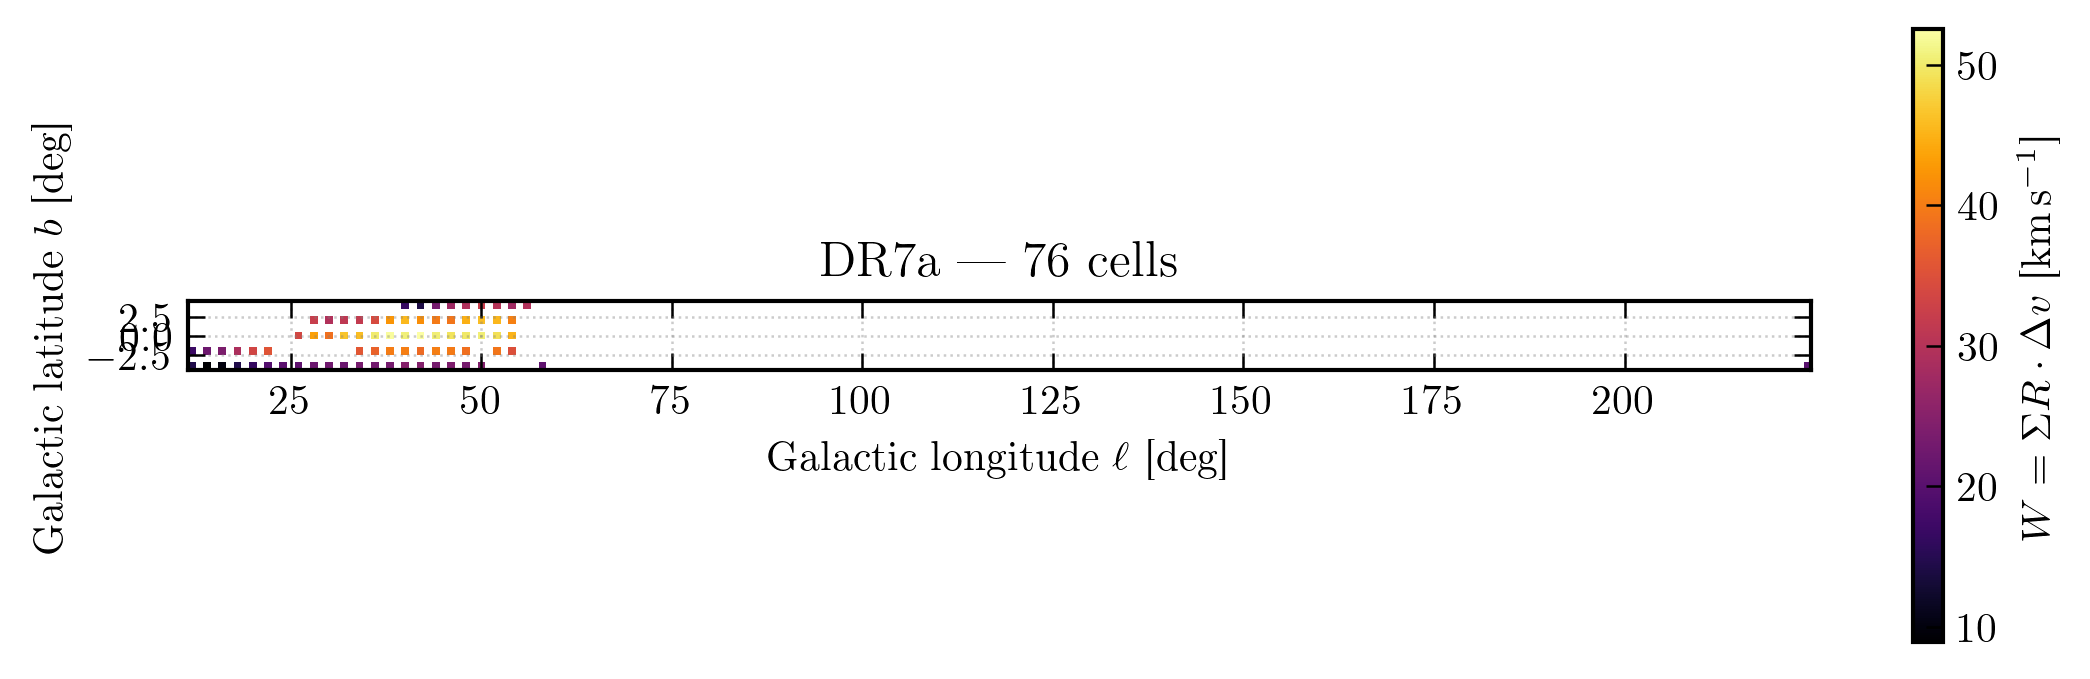

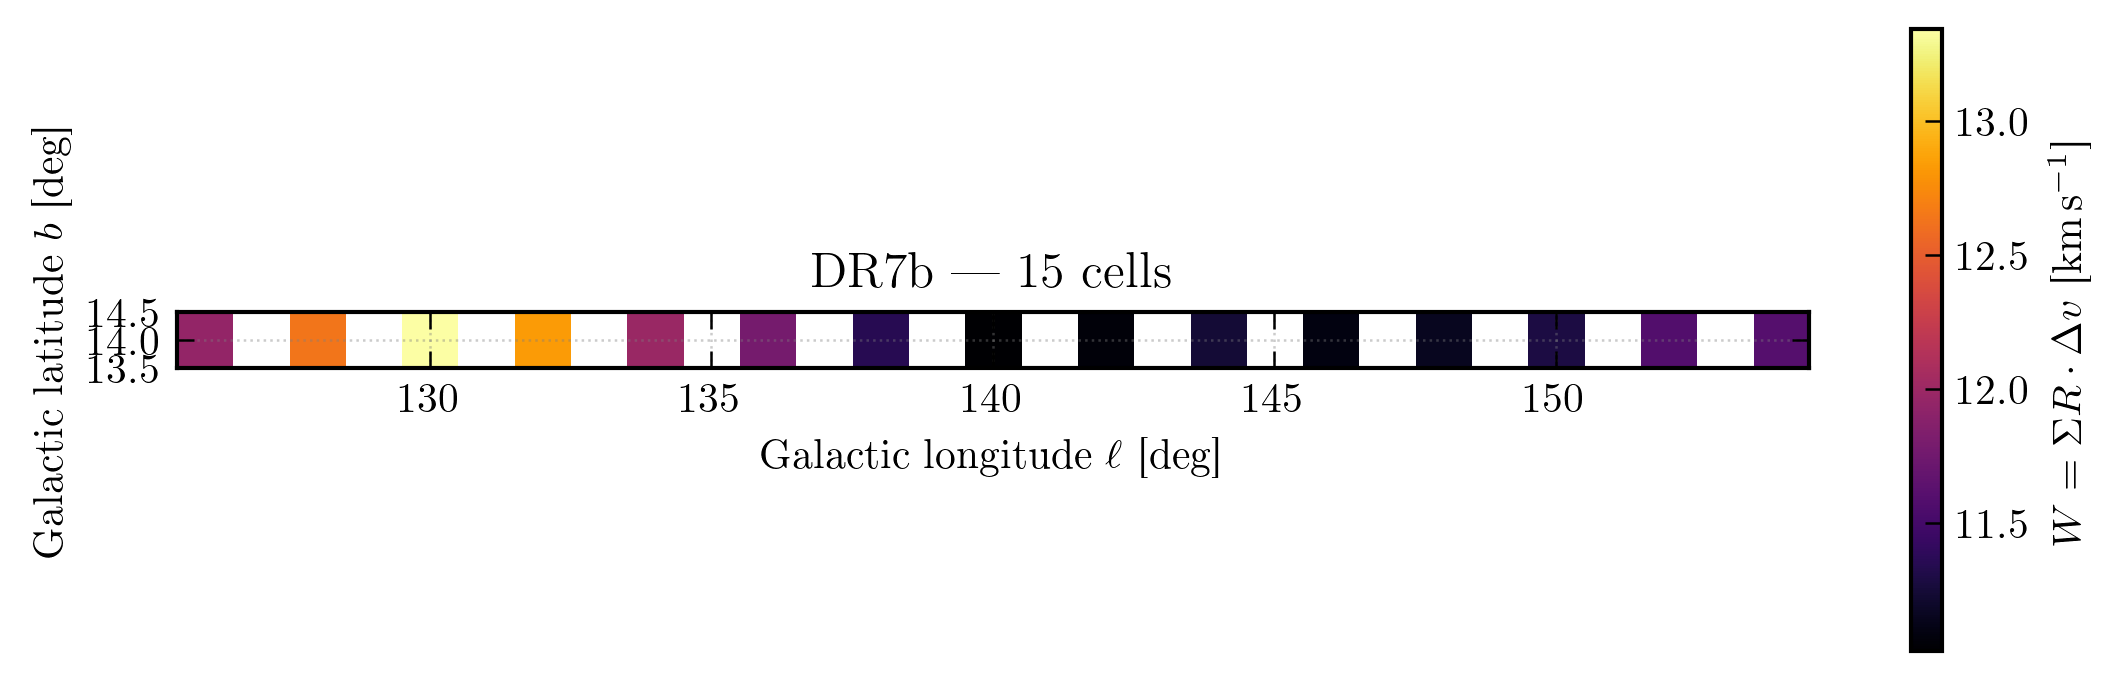

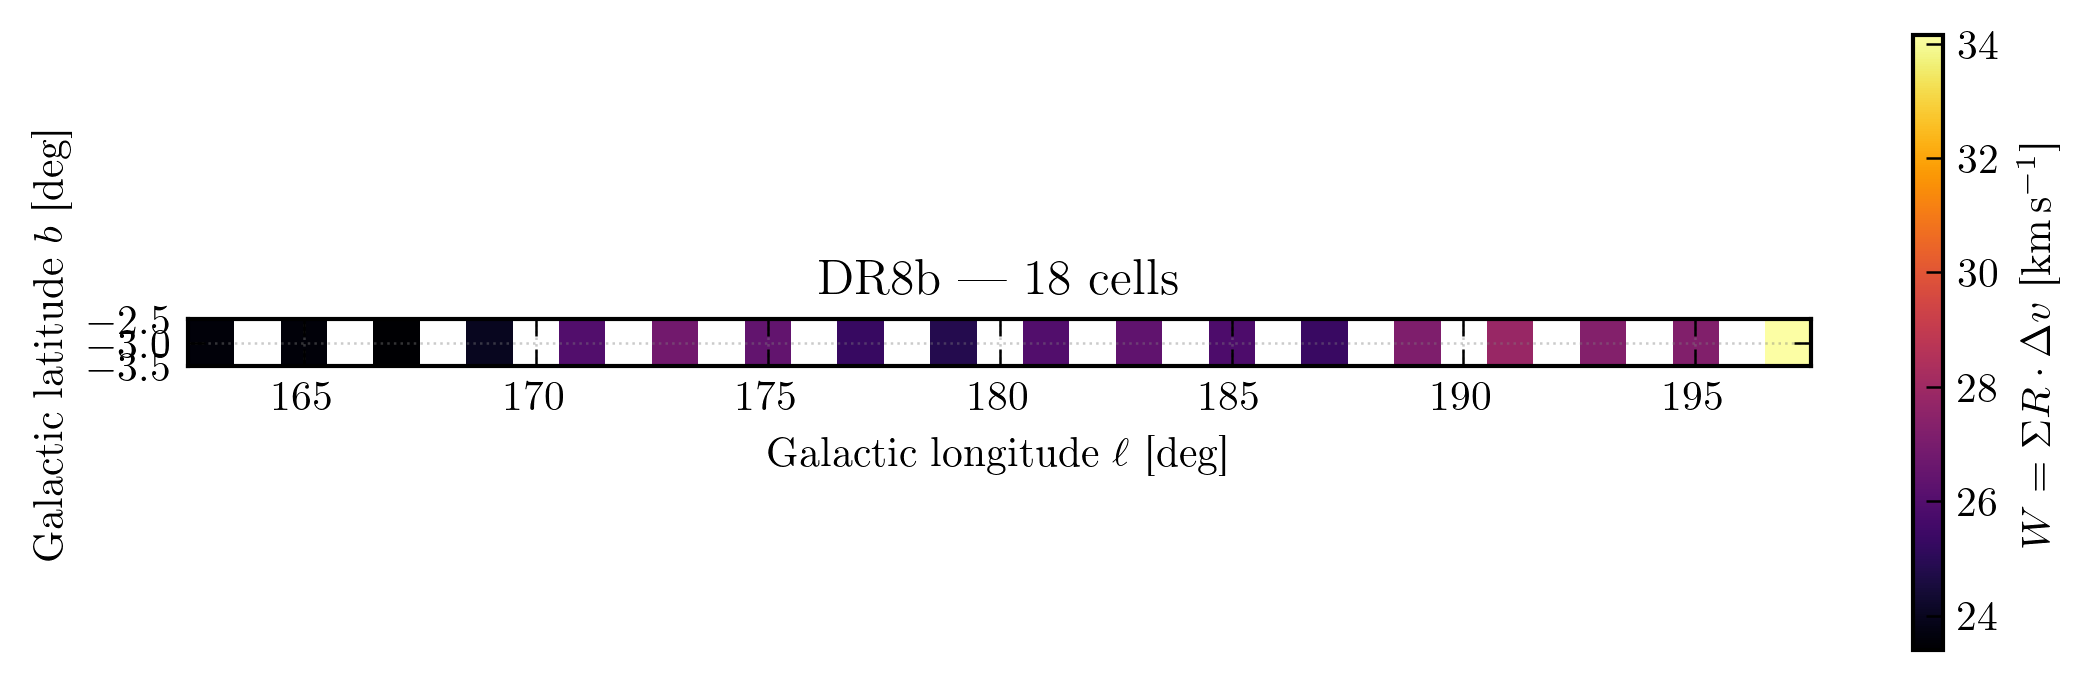

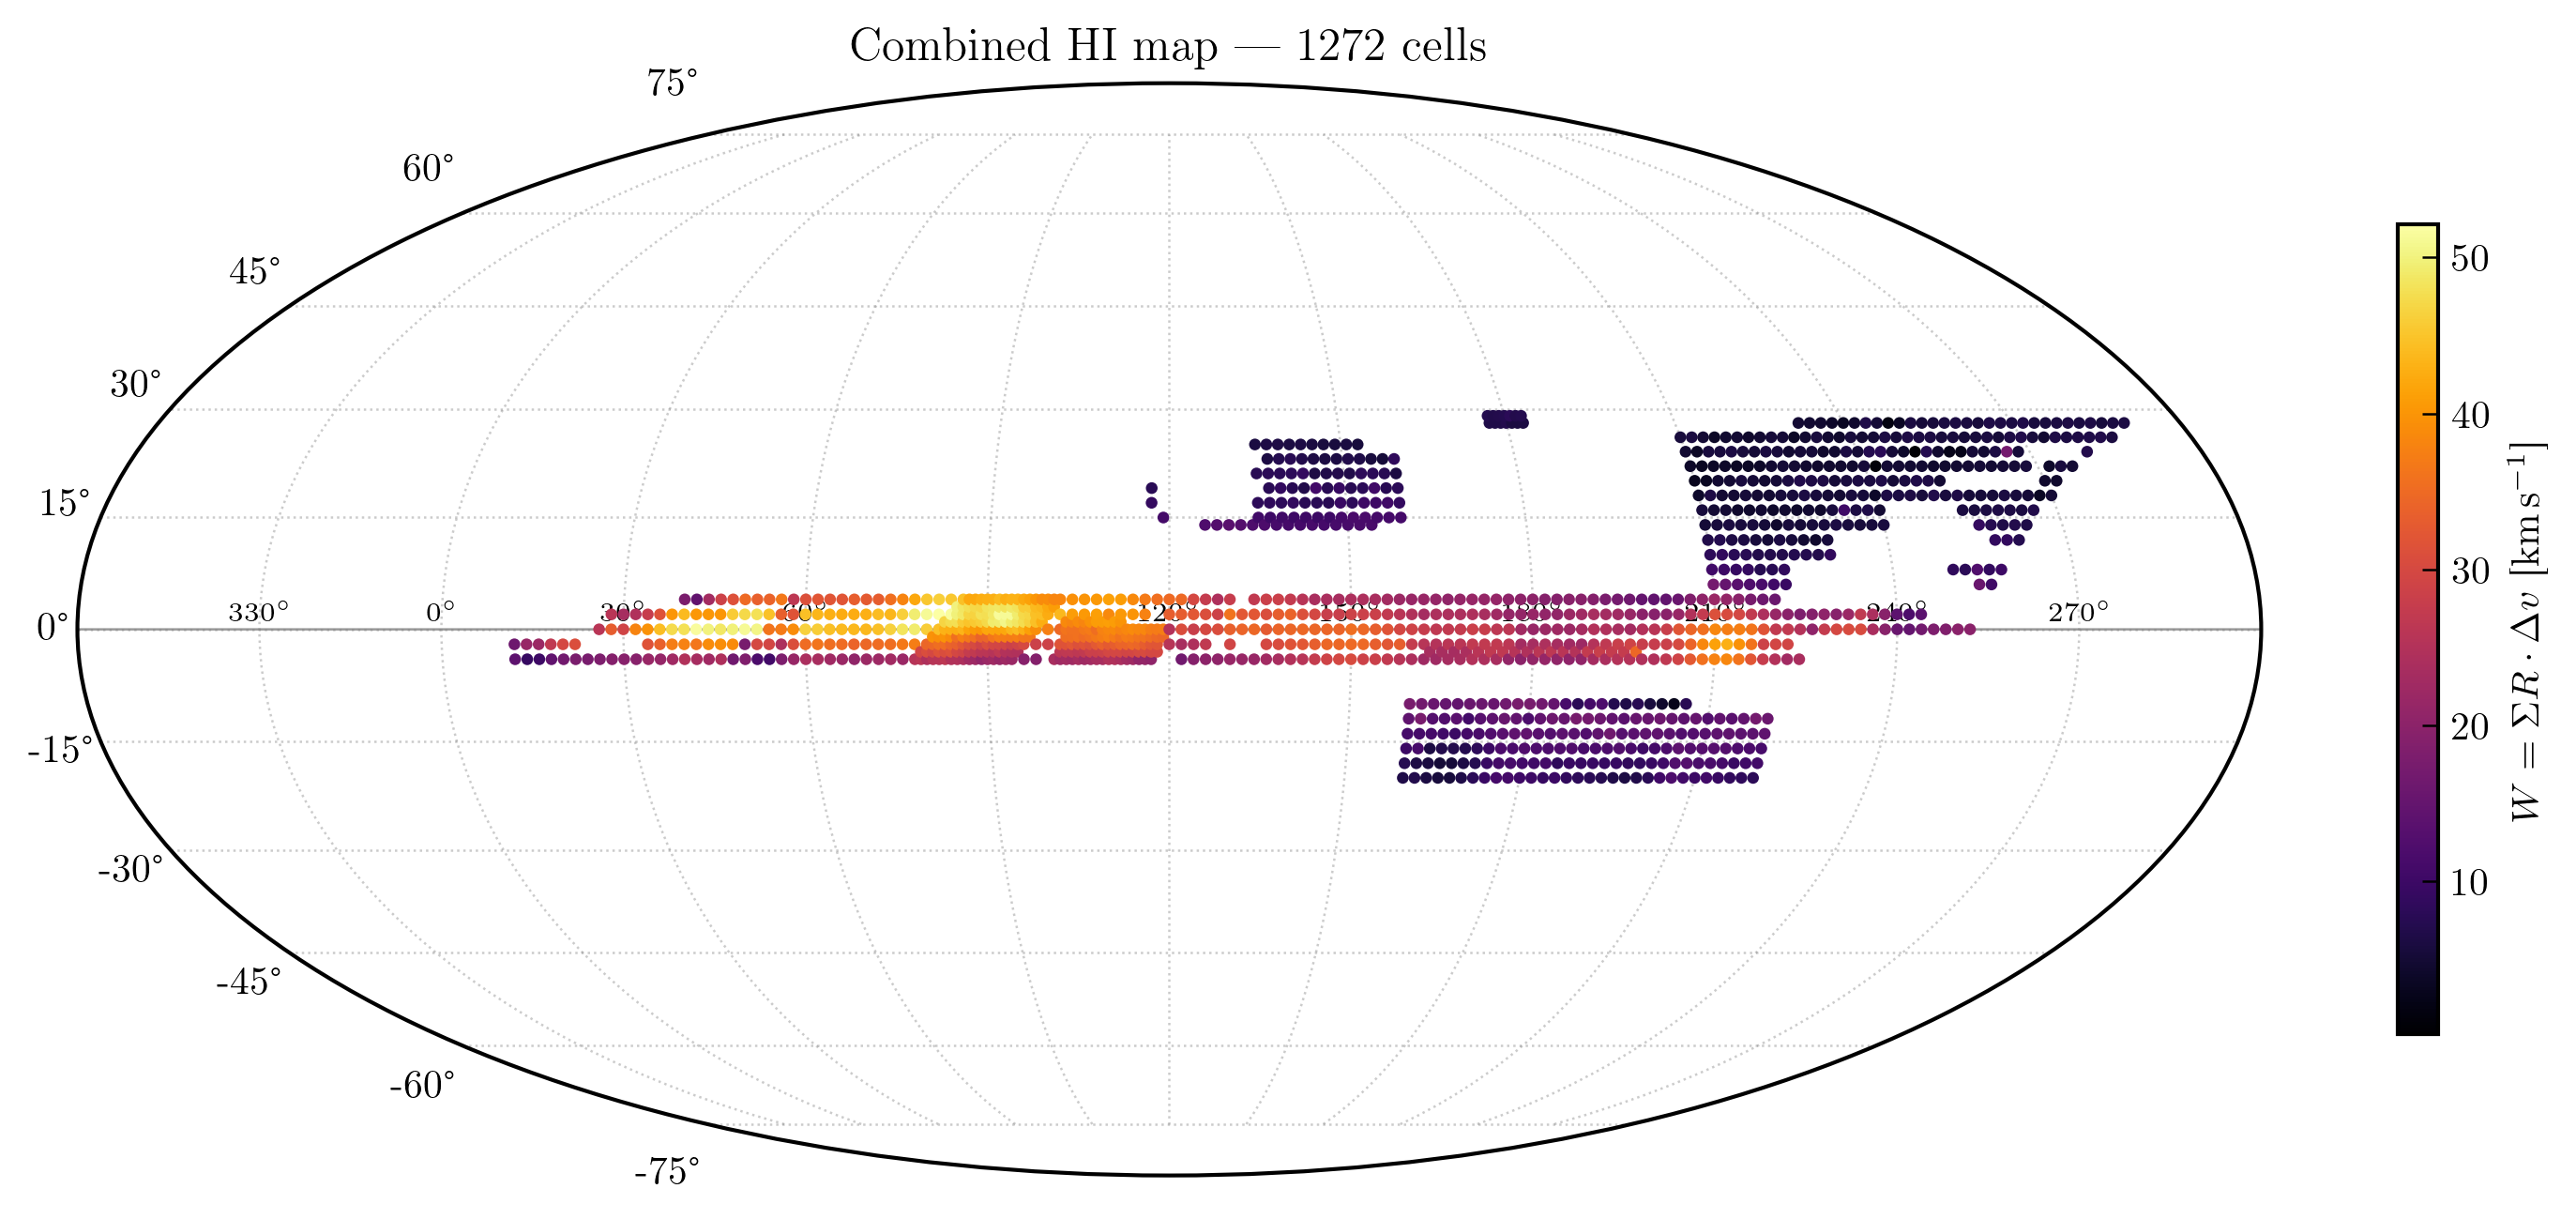

In [6]:
# Channel width in km/s
dv_kms = np.abs(np.median(np.diff(v_overlap)))
n_overlap_ch = overlap_mask.sum()

print(f'dv = {dv_kms:.3f} km/s per channel')
print(f'Overlap channels: {n_overlap_ch}')
print(f'Total velocity range: {n_overlap_ch * dv_kms:.1f} km/s')

# --- Per-DR flat maps ---
for dr in DATA_RELEASES:
    dr_results = {(l, b): v for (d, l, b), v in cell_results.items() if d == dr}
    if not dr_results:
        continue
    gl, gb, vals = compute_cell_W(dr_results, dv_kms)
    fig, ax = plot_heatmap(gl, gb, vals,
                           cbar_label=r"$W = \Sigma R \cdot \Delta v$ [km\,s$^{-1}$]",
                           cmap="inferno",
                           title=f'{dr} --- {len(vals)} cells')
    plt.show()

# --- Combined Mollweide projection ---
MOLL_CENTER_L = 120.0

gl_all, gb_all, W_all = compute_cell_W(cell_results_combined, dv_kms)
fig, ax = plot_survey_mollweide(
    gl_all, gb_all, W_all,
    center_l=MOLL_CENTER_L,
    cbar_label=r"$W = \Sigma R \cdot \Delta v$ [km\,s$^{-1}$]",
    cmap="inferno",
    marker_size=SS_FINE,
    title=f'Combined HI map --- {len(W_all)} cells',
)
plt.show()

## 5. All spectra per DR

In [7]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("spectra_per_dr.pdf") as pdf:
    for dr in DATA_RELEASES:
        dr_spectra = {(l, b): cell_results[(d, l, b)]['R_overlap']
                      for (d, l, b) in cell_results if d == dr}
        if not dr_spectra:
            continue
        result = plot_spectra_grid(v_overlap, dr_spectra,
                                   ncols=5,
                                   color="C0",
                                   title=f'{dr} --- {len(dr_spectra)} pointings')
        figs = result if isinstance(result, list) else [result]
        for f in figs:
            pdf.savefig(f)
            plt.close(f)

print("Saved spectra_per_dr.pdf")

Saved spectra_per_dr.pdf


## 6. Summary

In [8]:
all_times = [r['time'] for r in records]
t0 = dt.datetime.fromtimestamp(min(all_times), tz=dt.UTC)
t1 = dt.datetime.fromtimestamp(max(all_times), tz=dt.UTC)
wall = max(all_times) - min(all_times)

# Recompute counts after outlier removal
n_cal = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'])

print(f'Scan grid:  {len(rows)} x {len(cols)} = {len(cell_results)} cells with data')
print(f'LO freqs:   {lo_unique} MHz')
print(f'Start:      {t0:%Y-%m-%d %H:%M:%S UTC}')
print(f'End:        {t1:%Y-%m-%d %H:%M:%S UTC}')
print(f'Duration:   {wall/60:.1f} min')
print(f'Dumps:      {N} ({n_cal} cal + {n_sci} science)')
print(f'Channels:   {NFFT} (dnu={df_khz:.2f} kHz)')

Scan grid:  15 x 52 = 1281 cells with data
LO freqs:   [1420.0, 1421.0] MHz
Start:      2026-04-16 09:57:55 UTC
End:        2026-04-21 22:10:47 UTC
Duration:   7932.9 min
Dumps:      10751 (84 cal + 10667 science)
Channels:   1024 (dnu=2.50 kHz)
